In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("insurance.csv")

In [3]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


<Axes: xlabel='sex', ylabel='count'>

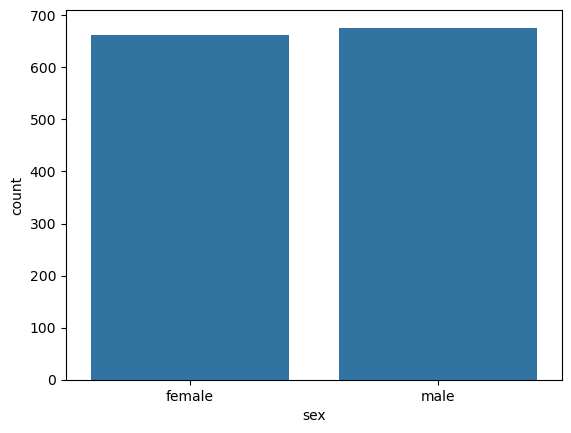

In [6]:
sns.countplot(data=data,x="sex")

<Axes: xlabel='smoker', ylabel='count'>

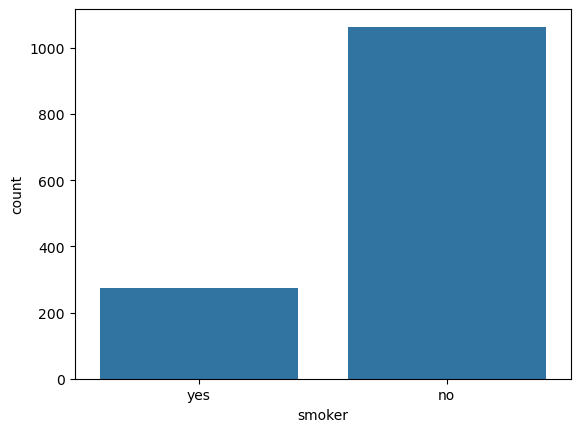

In [7]:
sns.countplot(data=data,x="smoker")

<Axes: xlabel='region', ylabel='count'>

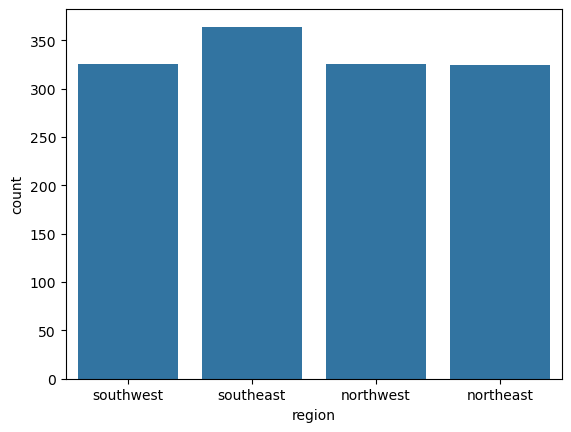

In [8]:
sns.countplot(data=data,x="region")

<Axes: xlabel='age', ylabel='charges'>

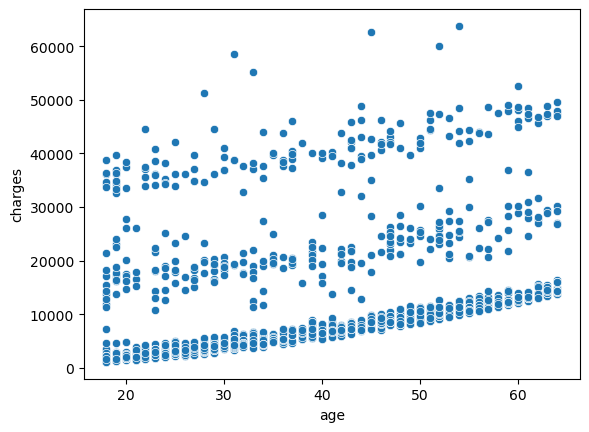

In [9]:
sns.scatterplot(data=data,x="age",y="charges")

In [10]:
data.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [11]:
data["sex"] = data["sex"].map({"male" :0,"female":1})

In [12]:
data["smoker"] = data["smoker"].map({"no" :0,"yes":1})

In [14]:
data["sex"].value_counts()

sex
0    676
1    662
Name: count, dtype: int64

In [16]:
X = data.drop("charges",axis=1)
y = data["charges"]

In [17]:
from sklearn.model_selection import train_test_split


In [18]:
X_train, X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [20]:
categorical_Cols = ["region"]
preprocessor = ColumnTransformer(transformers=[
    ("transformer",OneHotEncoder(drop="first",handle_unknown="ignore"),categorical_Cols)
],remainder="passthrough")

In [21]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [22]:
X_train

array([[ 1.   ,  0.   ,  0.   , ..., 19.95 ,  2.   ,  0.   ],
       [ 0.   ,  0.   ,  0.   , ..., 24.32 ,  0.   ,  0.   ],
       [ 0.   ,  1.   ,  0.   , ..., 24.86 ,  0.   ,  0.   ],
       ...,
       [ 0.   ,  0.   ,  0.   , ..., 25.175,  0.   ,  0.   ],
       [ 0.   ,  0.   ,  1.   , ..., 47.6  ,  2.   ,  1.   ],
       [ 0.   ,  0.   ,  1.   , ..., 29.9  ,  0.   ,  0.   ]],
      shape=(1070, 8))

In [25]:
from lightgbm import LGBMRegressor

In [27]:
model = LGBMRegressor()

In [28]:
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000818 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 319
[LightGBM] [Info] Number of data points in the train set: 1070, number of used features: 8
[LightGBM] [Info] Start training from score 13346.089733


C:\Users\erdem\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [29]:
from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error

In [30]:
print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))

0.867584212350846
2623.205455082831
20557383.0620152


In [31]:
param_grid = {
    "num_leaves" : [31,50,70],
    "n_estimators" : [100,300,1000],
    "max_depth": [-1,5,10],
    "learning_rate" : [0.01,0.05,0.1],
    "min_chield_samples" : [10,20,30],
    "subsample" : [0.6,0.8,1],
    "colsample_bytree" : [0.6,0.8],
    "reg_alpha" : [0,0.5,1]
    
}

In [32]:
from sklearn.model_selection import RandomizedSearchCV

In [33]:
import warnings
warnings.filterwarnings("ignore")

In [35]:
rsc = RandomizedSearchCV(
    estimator=LGBMRegressor(verbosity=-1),
    param_distributions=param_grid,
    cv=5,
    verbose=0,
    random_state=15,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

In [36]:
rsc.fit(X_train,y_train)

,estimator,LGBMRegressor(verbosity=-1)
,param_distributions,"{'colsample_bytree': [0.6, 0.8], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [-1, 5, ...], 'min_chield_samples': [10, 20, ...], ...}"
,n_iter,10
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,15
,error_score,nan


In [37]:
rsc.best_params_

{'subsample': 0.8,
 'reg_alpha': 0.5,
 'num_leaves': 31,
 'n_estimators': 300,
 'min_chield_samples': 20,
 'max_depth': 5,
 'learning_rate': 0.05,
 'colsample_bytree': 0.8}

In [40]:
y_pred = rsc.predict(X_test)

In [41]:
print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))

0.8749142212493662
2509.845364403746
19419408.478696525


In [42]:
from scipy.stats import boxcox

In [43]:
y_train_transformed, lambda_y = boxcox(y_train)

In [44]:
rsc.fit(X_train,y_train_transformed)

,estimator,LGBMRegressor(verbosity=-1)
,param_distributions,"{'colsample_bytree': [0.6, 0.8], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [-1, 5, ...], 'min_chield_samples': [10, 20, ...], ...}"
,n_iter,10
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,15
,error_score,nan


In [45]:
y_pred_transformed = rsc.predict(X_test)

In [47]:
print(r2_score(y_test,y_pred_transformed))
print(mean_absolute_error(y_test,y_pred_transformed))
print(mean_squared_error(y_test,y_pred_transformed))

-1.08106334412463
12956.288491242041
323082444.3293769


In [48]:
def lambda_inverse(y,lambda_):
    if lambda_ == 0:
        return np.exp(y)
    else:
        return np.power(y*lambda_+1,1/lambda_)


In [49]:
y_pred_original = lambda_inverse(y_pred_transformed,lambda_y)

In [50]:
print(r2_score(y_test,y_pred_original))
print(mean_absolute_error(y_test,y_pred_original))
print(mean_squared_error(y_test,y_pred_original))

0.8712299492873239
2201.271268208029
19991387.027274303
